# House Classification 2.1

## Data Preparation and Visualisation
This notebook focuses on the data-preparation stage before model development. It uses the official Kaggle House Prices dataset, creates the `Expensive` classification target from `SalePrice`, and builds a cleaner feature matrix using domain-aware preprocessing.

The Kaggle `test.csv` is kept separate because it does not contain true `SalePrice` labels. It is prepared with the same transformations so it can be used later for prediction.

## 1. Load Kaggle Data
We load the official Kaggle files:
- `train.csv`: labelled data with `SalePrice`, used for analysis and training.
- `test.csv`: unlabelled data without `SalePrice`, prepared later for prediction.
- `sample_submission.csv`: example submission format, not a true label source.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

KAGGLE_DIR = Path("house-prices-advanced-regression-techniques")
TRAIN_PATH = KAGGLE_DIR / "train.csv"
TEST_PATH = KAGGLE_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = KAGGLE_DIR / "sample_submission.csv"

EXPENSIVE_QUANTILE = 0.85
TARGET_COL = "Expensive"

raw_train = pd.read_csv(TRAIN_PATH)
raw_test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("Train shape:", raw_train.shape)
print("Test shape:", raw_test.shape)
print("Sample submission shape:", sample_submission.shape)
print("Train has SalePrice:", "SalePrice" in raw_train.columns)
print("Test has SalePrice:", "SalePrice" in raw_test.columns)
display(raw_train.head())

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)
Train has SalePrice: True
Test has SalePrice: False


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Initial Data Overview
Before cleaning, we inspect shape, data types, duplicates, and the target price distribution. This step prevents accidental assumptions about the dataset.

In [31]:
overview = pd.DataFrame({
    "rows": [raw_train.shape[0], raw_test.shape[0]],
    "columns": [raw_train.shape[1], raw_test.shape[1]],
    "duplicate_rows": [raw_train.duplicated().sum(), raw_test.duplicated().sum()],
    "duplicate_ids": [raw_train["Id"].duplicated().sum(), raw_test["Id"].duplicated().sum()],
}, index=["train", "test"])

print("Dataset overview:")
display(overview)

print("Missing values in train dataset:")
dtype_summary = raw_train.dtypes.value_counts().rename_axis("dtype").reset_index(name="count")
display(dtype_summary)

print("SalePrice distribution summary:")
display(raw_train["SalePrice"].describe().to_frame().round(2).T)

Dataset overview:


,rows,columns,duplicate_rows,duplicate_ids
train,1460,81,0,0
test,1459,80,0,0


Missing values in train dataset:


,dtype,count
0,object,43
1,int64,35
2,float64,3


SalePrice distribution summary:


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.2,79442.5,34900.0,129975.0,163000.0,214000.0,755000.0


## 3. Create Classification Target
`Expensive` is created from the top 15% of `SalePrice`. The continuous `SalePrice` column is then removed from the modelling features to avoid leakage.

In [32]:
EXPENSIVE_THRESHOLD = raw_train["SalePrice"].quantile(EXPENSIVE_QUANTILE)

train_with_target = raw_train.copy()
train_with_target[TARGET_COL] = (train_with_target["SalePrice"] >= EXPENSIVE_THRESHOLD).astype(int)

print(f"Expensive threshold: SalePrice >= {EXPENSIVE_THRESHOLD:,.0f}")
print("Class counts:")
print(train_with_target[TARGET_COL].value_counts())
print("\nClass percentages:")
print((train_with_target[TARGET_COL].value_counts(normalize=True) * 100).round(2))

Expensive threshold: SalePrice >= 250,000
Class counts:
0    1235
1     225
Name: Expensive, dtype: int64

Class percentages:
0    84.59
1    15.41
Name: Expensive, dtype: float64


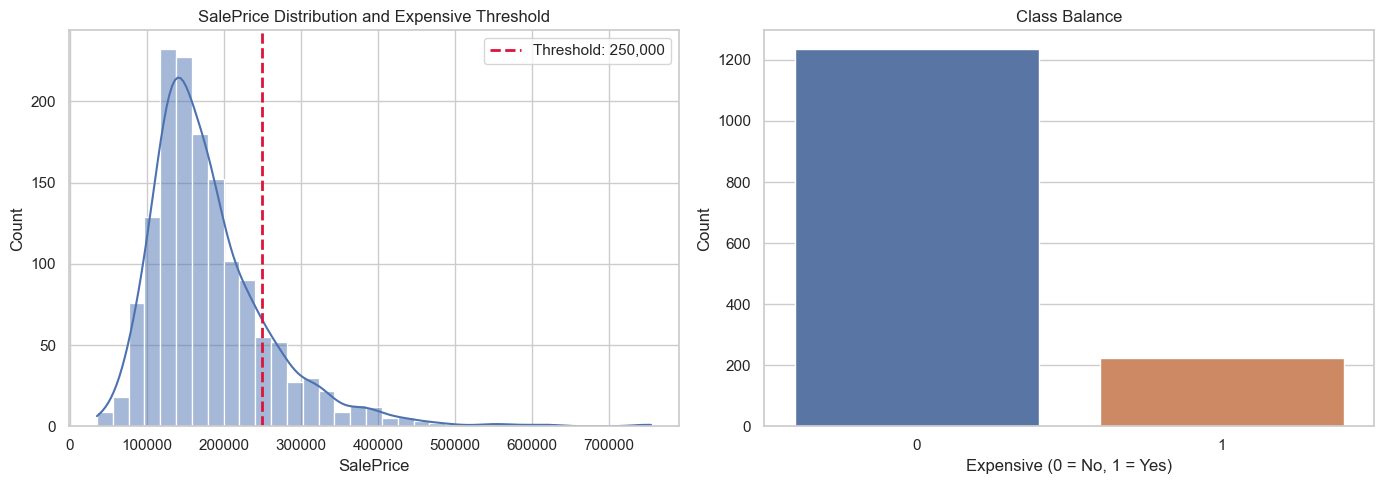

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(raw_train["SalePrice"], kde=True, bins=35, ax=axes[0])
axes[0].axvline(EXPENSIVE_THRESHOLD, color="crimson", linestyle="--", linewidth=2, label=f"Threshold: {EXPENSIVE_THRESHOLD:,.0f}")
axes[0].set_title("SalePrice Distribution and Expensive Threshold")
axes[0].set_xlabel("SalePrice")
axes[0].legend()

sns.countplot(data=train_with_target, x=TARGET_COL, ax=axes[1])
axes[1].set_title("Class Balance")
axes[1].set_xlabel("Expensive (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Plot interpretation:** The SalePrice histogram shows a right-skewed price distribution: most houses are in the lower-to-middle price range, while a smaller number of properties are very expensive. The red threshold line marks the cutoff used to create `Expensive = 1`. The class-balance plot confirms that this is an imbalanced classification problem, with many more non-expensive houses than expensive houses.

## 4. Missing Values Analysis
Missing values have different meanings in this dataset. Some missing values mean absence of a feature, such as no garage or no basement. Others are unknown numeric values and need imputation.

,PoolQC,MiscFeature,Alley,Fence,FireplaceQu,LotFrontage,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,BsmtExposure,BsmtFinType2,BsmtFinType1,BsmtCond,BsmtQual,MasVnrArea,MasVnrType,Electrical
missing_count,1453.000000,1406.00000,1369.000000,1179.000000,690.000000,259.000000,81.000000,81.000000,81.000000,81.000000,81.000000,38.00000,38.00000,37.000000,37.000000,37.000000,8.000000,8.000000,1.000000
missing_percent,99.520548,96.30137,93.767123,80.753425,47.260274,17.739726,5.547945,5.547945,5.547945,5.547945,5.547945,2.60274,2.60274,2.534247,2.534247,2.534247,0.547945,0.547945,0.068493


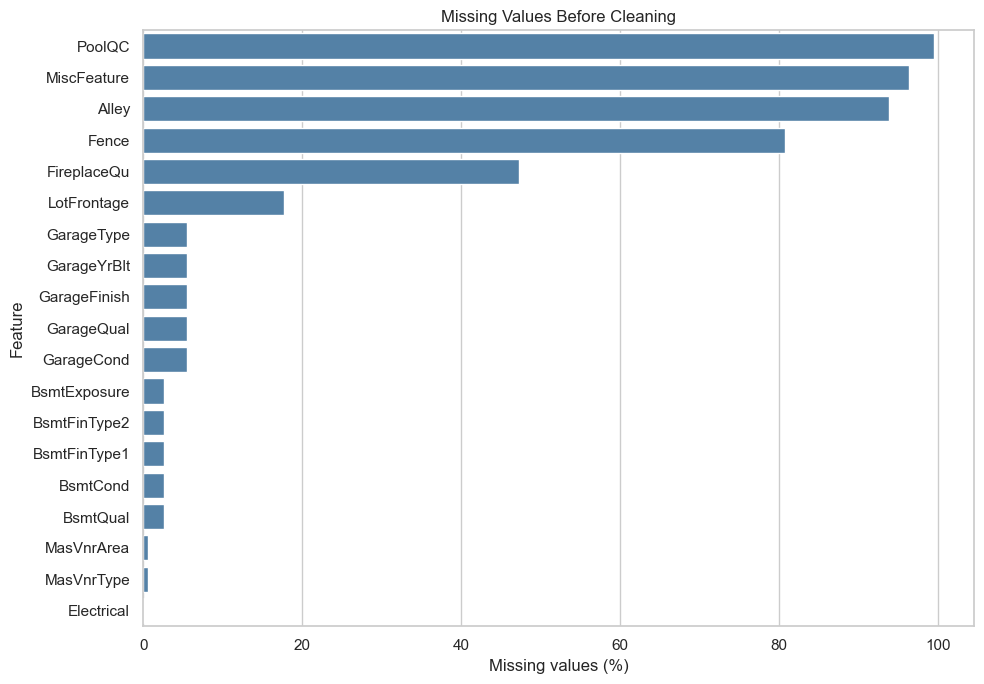

In [34]:
def missing_table(df):
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
    })
    return missing[missing["missing_count"] > 0].sort_values("missing_percent", ascending=False)

missing_before = missing_table(train_with_target)
display(missing_before.T)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=missing_before.reset_index().rename(columns={"index": "feature"}),
    x="missing_percent",
    y="feature",
    color="steelblue",
)
plt.title("Missing Values Before Cleaning")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Plot interpretation:** The missing-value plot shows that missingness is concentrated in a small set of housing features. Many of these missing values are meaningful rather than random: for example, missing `PoolQC`, `Alley`, `Fence`, or garage/basement quality often means the house does not have that feature. This supports using domain-aware filling instead of simple blanket imputation.

## 5. Domain-Aware Missing Value Treatment
The Kaggle data description shows that several `NaN` values mean the house does not have that feature. These should be filled with `None` for categorical variables or `0` for numeric area/count variables.

`LotFrontage` is treated differently: it is filled with the median frontage of the same `Neighborhood`, because nearby houses usually have similar street frontage.

In [35]:
none_fill_cols = [
    "Alley", "PoolQC", "Fence", "MiscFeature", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]

zero_fill_cols = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
]

print("Categorical absence columns present:", [c for c in none_fill_cols if c in raw_train.columns])
print("Numeric absence columns present:", [c for c in zero_fill_cols if c in raw_train.columns])

Categorical absence columns present: ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
Numeric absence columns present: ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']


## 6. Outlier Analysis
The original Kaggle competition discussion commonly flags very large houses with unusually low prices. We visualise these points before deciding whether to remove them from the training data.

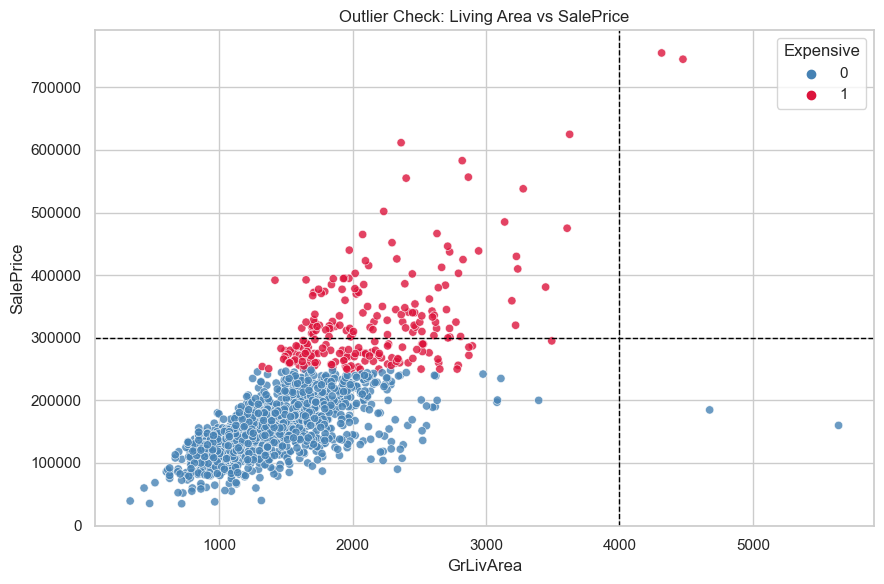

Potential outlier Ids: [524, 1299]


,Id,GrLivArea,SalePrice,Expensive
523,524,4676,184750,0
1298,1299,5642,160000,0


In [36]:
outlier_mask = (train_with_target["GrLivArea"] > 4000) & (train_with_target["SalePrice"] < 300000)
outlier_ids = train_with_target.loc[outlier_mask, "Id"].tolist()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=train_with_target, x="GrLivArea", y="SalePrice", 
                hue=TARGET_COL, palette={0: "steelblue", 1: "crimson"}, alpha=0.8)
plt.axvline(4000, color="black", linestyle="--", linewidth=1)
plt.axhline(300000, color="black", linestyle="--", linewidth=1)
plt.title("Outlier Check: Living Area vs SalePrice")
plt.tight_layout()
plt.show()

print("Potential outlier Ids:", outlier_ids)
display(train_with_target.loc[outlier_mask, ["Id", "GrLivArea", "SalePrice", TARGET_COL]])

**Plot interpretation:** The scatterplot compares living area with sale price. Most houses follow the expected pattern where larger living area is associated with higher price. The two highlighted extreme cases have very large living areas but relatively low sale prices, so they are treated as outliers and removed from the training analysis to reduce distortion.

In [37]:
train_analysis = train_with_target.loc[~outlier_mask].copy()
print("Rows before outlier removal:", len(train_with_target))
print("Rows after outlier removal:", len(train_analysis))
print("Rows removed:", int(outlier_mask.sum()))

Rows before outlier removal: 1460
Rows after outlier removal: 1458
Rows removed: 2


## 7. Feature Engineering
Create features that better represent housing value drivers:
- total usable square footage,
- total bathrooms,
- house age and remodel age,
- binary indicators for garage, basement, fireplace, pool, porch, and second floor.

In [38]:
def add_engineered_features(df):
    df = df.copy()
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBathrooms"] = (
        df["FullBath"] + 0.5 * df["HalfBath"] +
        df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    )
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    df["HasPorch"] = ((df["OpenPorchSF"] + df["EnclosedPorch"] 
                       + df["3SsnPorch"] + df["ScreenPorch"]) > 0).astype(int)
    df["HasSecondFloor"] = (df["2ndFlrSF"] > 0).astype(int)
    return df

feature_demo = add_engineered_features(train_analysis.drop(columns=["SalePrice"]))
new_features = ["TotalSF", "TotalBathrooms", "HouseAge", "RemodelAge", "IsRemodeled", "HasGarage",
                "HasBasement", "HasFireplace", "HasPool", "HasPorch", "HasSecondFloor"]
display(feature_demo[new_features + [TARGET_COL]].head())

,TotalSF,TotalBathrooms,HouseAge,RemodelAge,IsRemodeled,HasGarage,HasBasement,HasFireplace,HasPool,HasPorch,HasSecondFloor,Expensive
0,2566,3.5,5,5,0,1,1,0,0,1,1,0
1,2524,2.5,31,31,0,1,1,1,0,0,0,0
2,2706,3.5,7,6,1,1,1,1,0,1,1,0
3,2473,2.0,91,36,1,1,1,1,0,1,1,0
4,3343,3.5,8,8,0,1,1,1,0,1,1,1


## 8. Reusable Cleaning Pipeline for Train and Test
This stage creates metadata from the training data, then applies the same cleaning logic to both train and test. This prevents train/test mismatch later.

In [39]:
def fit_preprocessing_metadata(train_df, target_col=TARGET_COL, rare_min_count=10):
    feature_df = train_df.drop(columns=[target_col, "SalePrice"], errors="ignore").copy()

    neighborhood_frontage = feature_df.groupby("Neighborhood")["LotFrontage"].median()
    global_frontage = feature_df["LotFrontage"].median()

    categorical_cols = feature_df.select_dtypes(include="object").columns.tolist()
    numeric_cols = feature_df.select_dtypes(exclude="object").columns.tolist()

    categorical_modes = feature_df[categorical_cols].mode(dropna=True).iloc[0].to_dict()
    numeric_medians = feature_df[numeric_cols].median(numeric_only=True).to_dict()

    rare_levels = {}
    for col in categorical_cols:
        counts = feature_df[col].fillna("Missing").value_counts()
        rare_levels[col] = counts[counts < rare_min_count].index.tolist()

    return {
        "neighborhood_frontage": neighborhood_frontage,
        "global_frontage": global_frontage,
        "categorical_modes": categorical_modes,
        "numeric_medians": numeric_medians,
        "rare_levels": rare_levels,
        "rare_min_count": rare_min_count,
    }


def clean_housing_features(df, metadata, target_col=TARGET_COL):
    df = df.copy()
    target = df[target_col].copy() if target_col in df.columns else None

    df = df.drop(columns=[target_col, "SalePrice"], errors="ignore")
    df = df.drop(columns=["Id"], errors="ignore")

    for col in none_fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    for col in zero_fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    if "LotFrontage" in df.columns:
        frontage_by_neighborhood = df["Neighborhood"].map(metadata["neighborhood_frontage"])
        df["LotFrontage"] = df["LotFrontage"].fillna(frontage_by_neighborhood)
        df["LotFrontage"] = df["LotFrontage"].fillna(metadata["global_frontage"])

    categorical_cols = df.select_dtypes(include="object").columns.tolist()
    numeric_cols = df.select_dtypes(exclude="object").columns.tolist()

    for col in categorical_cols:
        fill_value = metadata["categorical_modes"].get(col, "Missing")
        df[col] = df[col].fillna(fill_value)
        rare = metadata["rare_levels"].get(col, [])
        df[col] = df[col].where(~df[col].isin(rare), "Rare")

    for col in numeric_cols:
        fill_value = metadata["numeric_medians"].get(col, df[col].median())
        df[col] = df[col].fillna(fill_value)

    df = add_engineered_features(df)

    if target is not None:
        df[target_col] = target.values

    return df

preprocessing_metadata = fit_preprocessing_metadata(train_analysis)
clean_train = clean_housing_features(train_analysis, preprocessing_metadata)
clean_test = clean_housing_features(raw_test, preprocessing_metadata)

print("Clean train shape:", clean_train.shape)
print("Clean test shape:", clean_test.shape)
print("Missing values in clean train:", int(clean_train.isna().sum().sum()))
print("Missing values in clean test:", int(clean_test.isna().sum().sum()))
display(clean_train.head())

Clean train shape: (1458, 91)
Clean test shape: (1459, 90)
Missing values in clean train: 0
Missing values in clean test: 0


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBathrooms,HouseAge,RemodelAge,IsRemodeled,HasGarage,HasBasement,HasFireplace,HasPool,HasPorch,HasSecondFloor,Expensive
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,2566,3.5,5,5,0,1,1,0,0,1,1,0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,2524,2.5,31,31,0,1,1,1,0,0,0,0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,2706,3.5,7,6,1,1,1,1,0,1,1,0
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,2473,2.0,91,36,1,1,1,1,0,1,1,0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,3343,3.5,8,8,0,1,1,1,0,1,1,1


In [40]:
missing_after = missing_table(clean_train)

if missing_after.empty:
    print("No missing values remain in clean_train.")
else:
    display(missing_after)

summary_before_after = pd.DataFrame({
    "stage": ["before_cleaning", "after_cleaning"],
    "total_missing_values": [int(train_analysis.isna().sum().sum()), int(clean_train.isna().sum().sum())],
    "columns_with_missing": [int((train_analysis.isna().sum() > 0).sum()), int((clean_train.isna().sum() > 0).sum())],
})
display(summary_before_after)

No missing values remain in clean_train.


,stage,total_missing_values,columns_with_missing
0,before_cleaning,6958,19
1,after_cleaning,0,0


## 9. Visual EDA After Cleaning
These plots check whether the engineered and cleaned data behaves sensibly before modelling.

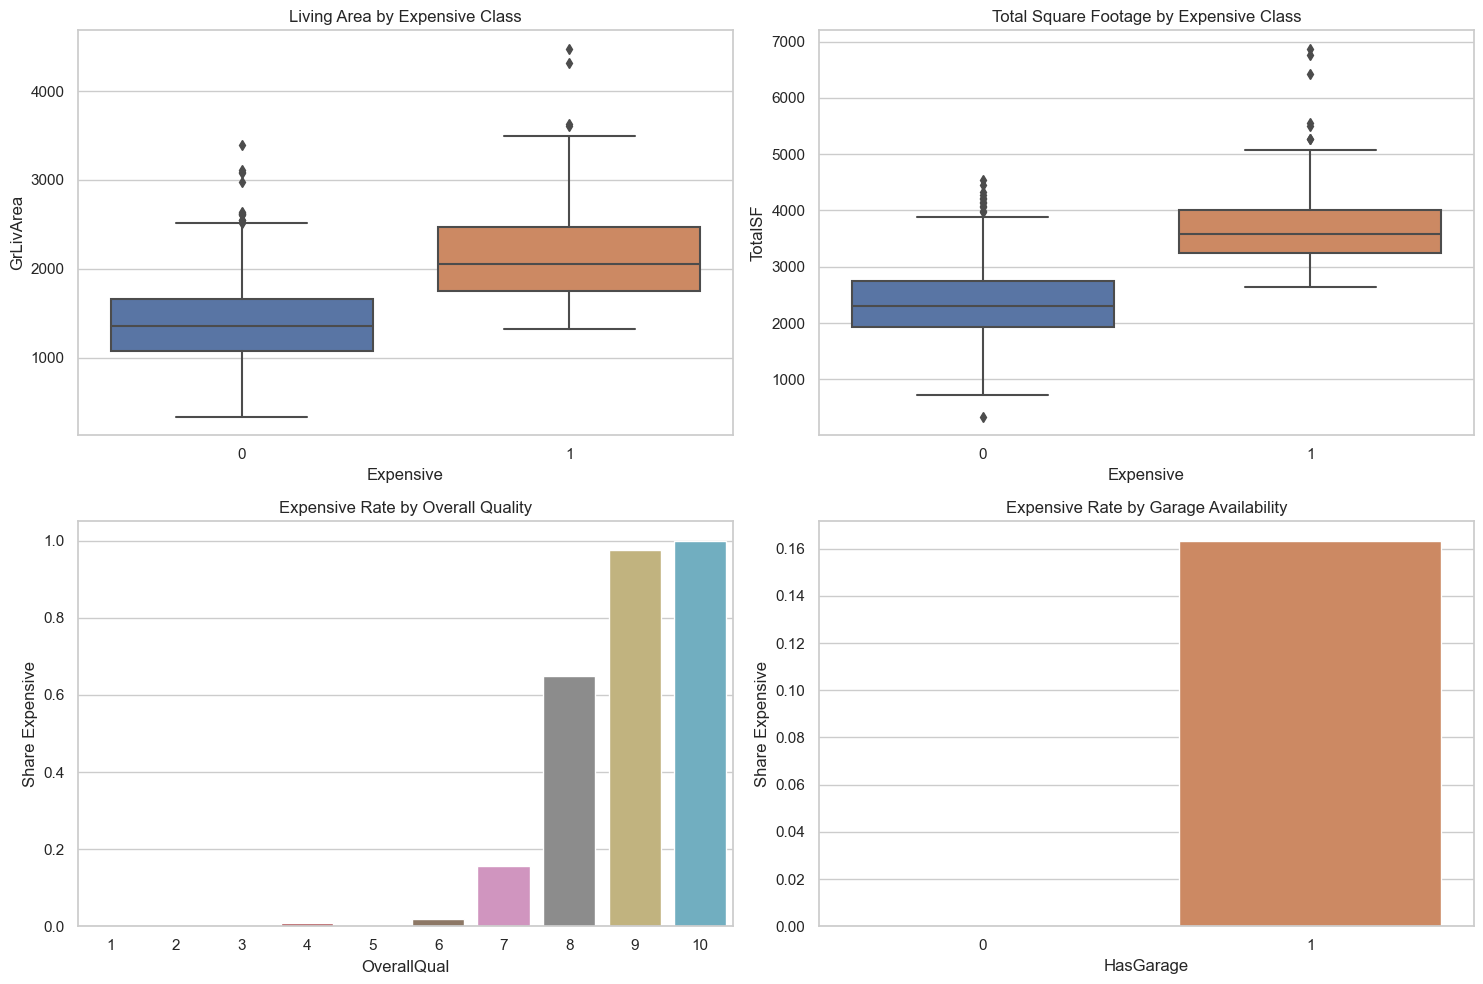

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=clean_train, x=TARGET_COL, y="GrLivArea", ax=axes[0, 0])
axes[0, 0].set_title("Living Area by Expensive Class")

sns.boxplot(data=clean_train, x=TARGET_COL, y="TotalSF", ax=axes[0, 1])
axes[0, 1].set_title("Total Square Footage by Expensive Class")

sns.barplot(data=clean_train, x="OverallQual", y=TARGET_COL, ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title("Expensive Rate by Overall Quality")
axes[1, 0].set_ylabel("Share Expensive")

sns.barplot(data=clean_train, x="HasGarage", y=TARGET_COL, ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title("Expensive Rate by Garage Availability")
axes[1, 1].set_ylabel("Share Expensive")

plt.tight_layout()
plt.show()

**Plot interpretation:** These plots check whether key cleaned and engineered features separate expensive from non-expensive houses. Expensive houses generally have larger living area, larger total square footage, higher overall quality, and are more likely to have a garage. This confirms that the engineered features are aligned with real housing-value logic.

,mean,count
Neighborhood,,
CollgCr,0.120000,150
SawyerW,0.135593,59
ClearCr,0.214286,28
Crawfor,0.235294,51
Somerst,0.313953,86
Veenker,0.363636,11
Timber,0.421053,38
StoneBr,0.640000,25
NridgHt,0.766234,77


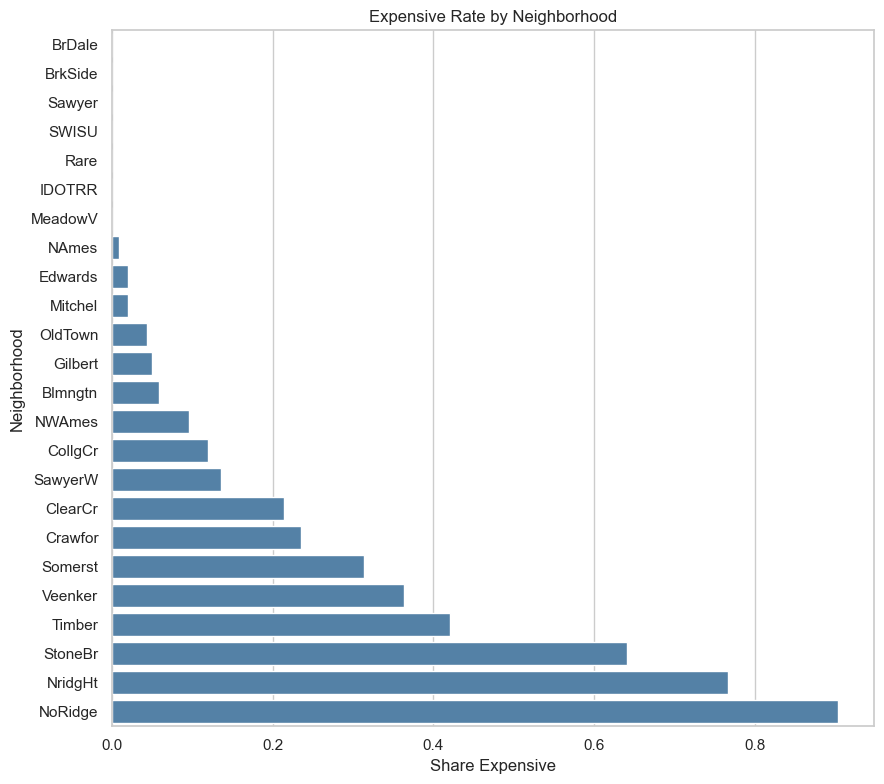

In [42]:
neighborhood_rate = clean_train.groupby("Neighborhood")[TARGET_COL].agg(["mean", "count"]).sort_values("mean")

display(neighborhood_rate.tail(10))

plt.figure(figsize=(9, 8))
sns.barplot(data=neighborhood_rate.reset_index(), x="mean", y="Neighborhood", color="steelblue")
plt.title("Expensive Rate by Neighborhood")
plt.xlabel("Share Expensive")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

**Plot interpretation:** The neighbourhood chart shows that location has a strong relationship with the expensive-house class. Some neighbourhoods have a much higher share of expensive properties than others. This means `Neighborhood` should be kept as an important categorical predictor during modelling.

,correlation_with_expensive
TotalSF,0.627897
OverallQual,0.600052
GrLivArea,0.548238
TotalBsmtSF,0.496909
GarageArea,0.488667
1stFlrSF,0.488638
GarageCars,0.464250
TotalBathrooms,0.422503
TotRmsAbvGrd,0.406707
MasVnrArea,0.394407


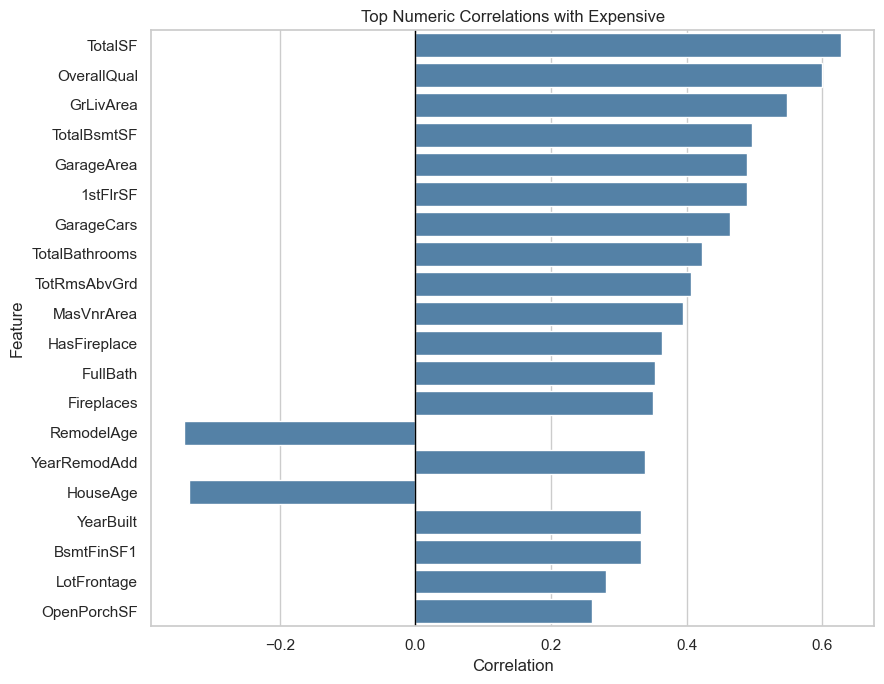

In [43]:
numeric_corr = clean_train.select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=lambda s: s.abs(), ascending=False)

display(numeric_corr.head(20).to_frame("correlation_with_expensive"))

plt.figure(figsize=(9, 7))
sns.barplot(x=numeric_corr.head(20).values, y=numeric_corr.head(20).index, color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Numeric Correlations with Expensive")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Plot interpretation:** The correlation chart ranks numeric variables by their relationship with `Expensive`. Quality, size, basement area, garage capacity, and engineered total-area features are among the strongest signals. Correlation does not prove causation, but it helps identify which numeric features are most useful before modelling.

## 10. Final Clean Feature Matrix
At this point, the data is ready for modelling. `clean_train` contains the target, while `X_clean` and `y_clean` separate features from labels. `clean_test` has the same feature-preparation logic applied to Kaggle's unlabelled test data.

In [44]:
X_clean = clean_train.drop(columns=[TARGET_COL])
y_clean = clean_train[TARGET_COL]

print("X_clean shape:", X_clean.shape)
print("y_clean shape:", y_clean.shape)
print("clean_test shape:", clean_test.shape)
print("Feature columns match test columns:", list(X_clean.columns) == list(clean_test.columns))

clean_summary = pd.DataFrame({
    "dataset": ["X_clean", "clean_test"],
    "rows": [X_clean.shape[0], clean_test.shape[0]],
    "columns": [X_clean.shape[1], clean_test.shape[1]],
    "missing_values": [int(X_clean.isna().sum().sum()), int(clean_test.isna().sum().sum())],
})
print("Cleaned dataset summary:")
display(clean_train.head())
print("\nSummary of cleaned datasets:")
display(clean_summary)
display(clean_train.info())

X_clean shape: (1458, 90)
y_clean shape: (1458,)
clean_test shape: (1459, 90)
Feature columns match test columns: True
Cleaned dataset summary:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBathrooms,HouseAge,RemodelAge,IsRemodeled,HasGarage,HasBasement,HasFireplace,HasPool,HasPorch,HasSecondFloor,Expensive
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,2566,3.5,5,5,0,1,1,0,0,1,1,0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,2524,2.5,31,31,0,1,1,1,0,0,0,0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,2706,3.5,7,6,1,1,1,1,0,1,1,0
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,2473,2.0,91,36,1,1,1,1,0,1,1,0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,3343,3.5,8,8,0,1,1,1,0,1,1,1



Summary of cleaned datasets:


,dataset,rows,columns,missing_values
0,X_clean,1458,90,0
1,clean_test,1459,90,0


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1458 entries, 0 to 1459
Data columns (total 91 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MSSubClass      1458 non-null   int64  
 1   MSZoning        1458 non-null   object 
 2   LotFrontage     1458 non-null   float64
 3   LotArea         1458 non-null   int64  
 4   Street          1458 non-null   object 
 5   Alley           1458 non-null   object 
 6   LotShape        1458 non-null   object 
 7   LandContour     1458 non-null   object 
 8   Utilities       1458 non-null   object 
 9   LotConfig       1458 non-null   object 
 10  LandSlope       1458 non-null   object 
 11  Neighborhood    1458 non-null   object 
 12  Condition1      1458 non-null   object 
 13  Condition2      1458 non-null   object 
 14  BldgType        1458 non-null   object 
 15  HouseStyle      1458 non-null   object 
 16  OverallQual     1458 non-null   int64  
 17  OverallCond     1458 non-null   i

None

## 11. Preprocessing Summary
The data-preparation stage now includes:
- Kaggle `train.csv` as the labelled modelling dataset.
- Kaggle `test.csv` kept separate for future prediction.
- Explicit `Expensive` target creation from the top 15% of `SalePrice`.
- `SalePrice` removed from features to prevent leakage.
- Domain-aware missing-value handling for basement, garage, pool, fence, alley, masonry veneer, and fireplace fields.
- Neighbourhood-median imputation for `LotFrontage`.
- Removal of the non-predictive `Id` feature.
- Rare category grouping to reduce noisy one-hot encoding later.
- Feature engineering for area, bathrooms, age, remodel status, and feature-availability indicators.
- Outlier review and removal of extreme `GrLivArea`/low-price points from the training analysis data.

The next notebook section should start modelling from `X_clean`, `y_clean`, and `clean_test`.